In [1]:
# Hyperparameters and paths
device_id = "cuda:0" # Device ID
time_steps = 5e5 # Timesteps
num_envs = 1
n_trials = 50
exp_set = 'set1'
num_robots = 2
max_steps = 1000

In [2]:
import os
import json
import copy
import itertools
import datetime
import numpy as np
import matplotlib.pyplot as plt
import pygame
import gymnasium as gym
import traceback
import optuna
np.random.seed(33) # seeding

# Training libraries
from stable_baselines3.common.callbacks import LogEveryNTimesteps, EvalCallback, StopTrainingOnNoModelImprovement # logger
from stable_baselines3.common.env_util import make_vec_env # for making environments
# from stable_baselines3.common.logger import configure
from stable_baselines3.common.evaluation import evaluate_policy

pygame 2.6.1 (SDL 2.28.4, Python 3.11.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


/home/c/choton/miniconda3/envs/rl4pag/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-19 14:34:43.681234: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-19 14:34:43.698108: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768854883.715513  941520 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768854883.720879  941520 cuda_blas.c

In [3]:
# Function to check if a point is inside a polygon (Ray-casting algorithm)
def is_inside_polygon(point, poly):
    x, y = point
    inside = False
    n = len(poly)
    p1x, p1y = poly[0]
    for i in range(n + 1):
        p2x, p2y = poly[i % n]
        if min(p1y, p2y) < y <= max(p1y, p2y) and x <= max(p1x, p2x):
            if p1y != p2y:
                xinters = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
            if p1x == p2x or x <= xinters:
                inside = not inside
        p1x, p1y = p2x, p2y
    return inside

# Function to return minimum distance in a list of points
def compute_min_dist(x):
    x = np.array(x).astype('float32')
    dists = []
    for p1, p2 in itertools.combinations(x, 2):
        dist = np.linalg.norm(p1-p2)
        dists.append(dist)
    return float(np.min(dists))

# Load experiment json file
def load_experiment_dict_json(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)
    for set_name, cfg in data.items():
        # Convert field to list of tuples
        cfg["field"] = [tuple(p) for p in cfg["field"]]
        # Convert init_positions to NumPy arrays
        cfg["init_positions"] = [np.array(p, dtype=float) for p in cfg["init_positions"]]
        # Convert infected_locations to set of tuples
        cfg["infected_locations"] = [tuple(p) for p in cfg["infected_locations"]]
    return data

In [4]:
class MultiRobotEnv(gym.Env):
    metadata = {'render_modes': ['human', 'print', 'rgb_array'], "render_fps": 4}    
    def __init__(self, field_info, render_mode=None, wind_par=[0,0], num_robots=3, render_scale=10):
        super().__init__()

        # Screen, rendering (simulation) and field parameters
        self.field_info = copy.deepcopy(field_info)
        self.render_scale = render_scale # Scaling factor for rendering only 
        self.poly_vertices = self.field_info['field']  # Physics coordinates
        self.xs, self.ys = zip(*self.field_info['field']) # x and y values of the vertices of the polygonal field
        self.WIDTH, self.HEIGHT = max(self.xs) + 10, max(self.ys) + 10 # Boundary above the max values
        assert render_mode is None or render_mode in self.metadata["render_modes"] # Check valid render modes
        self.render_mode = render_mode
        self.screen = None
        self.clock = None

        # Robot parameters
        self.num_robots = num_robots
        self.robot_size = 2
        self.mass = 1.0
        self.thrust_power = 0.5 # Force applied per action
        self.max_speed = 5
        self.min_speed = -5
        self.init_robot_positions = np.array(self.field_info['init_positions'])[:self.num_robots]
        self.init_robot_capacities = np.array(self.field_info['robot_capacities'][:self.num_robots], dtype=np.float32)
        self.max_capacity = np.max(self.init_robot_capacities)
        self.wind_f_a, self.wind_beta_a = wind_par # Wind parameters: magnitude and angle

        # Infected locations with levels
        self.init_infected_locations = [(np.array([x, y]), level) for x, y, level in self.field_info['infected_locations']]
        self.max_infection_level = max(lvl for _, lvl in self.init_infected_locations)
        self.infected_radius = 5
        self.spray_sigma = self.infected_radius / 2.0
        self.n_infected = len(self.init_infected_locations)
        
        # Action space (ax, ay, spray) and Observation space (x, y, vx, vy, inf_loc): position and velocity for each robot and infected location
        self.action_space = gym.spaces.Box(
            low=np.array([[-1.0, -1.0, 0.0]] * self.num_robots),
            high=np.array([[1.0, 1.0, 1.0]] * self.num_robots), dtype=np.float32
        )
        self.observation_space = gym.spaces.Box(
            low=np.concatenate((
                np.zeros(self.num_robots * 2),                # (x, y) co-ordinates of each robot
                np.full(self.num_robots * 2, self.min_speed), # (v_x, v_y) velocities along x and y axis of each robot
                np.zeros(self.num_robots), # robot spraying capacities
                np.zeros(self.n_infected)  # infection levels of each infected locations
            )),
            high=np.concatenate((
                np.tile([self.WIDTH, self.HEIGHT], self.num_robots), # (x, y) co-ordinates of each robot
                np.full(self.num_robots * 2, self.max_speed), # (v_x, v_y) velocities along x and y axis of each robot
                np.full(self.num_robots, self.max_capacity), # Full capacity for all robots
                np.ones(self.n_infected) # infection levels of each infected locations
            )), dtype=np.float32
        )
        
        self.reset() # Reset environment and start

    def _get_obs(self):
        info = {f'robot{i}': {'position': self.robot_positions[i], 'capacity': self.robot_capacities[i]}
                    for i in range(self.num_robots)}
        infection_levels = np.array([lvl / self.max_infection_level 
                                     for _, lvl in self.infected_locations], dtype=np.float32) # Normalized infection levels for infected locations
        state = np.concatenate((self.robot_positions.flatten(), self.robot_velocities.flatten(),
                                self.robot_capacities, infection_levels), dtype=np.float32)
        return state, info

    def reset(self, seed=None, options={}):
        super().reset(seed=seed)
        self.robot_positions = copy.deepcopy(self.init_robot_positions) # Initial robot locations
        self.robot_velocities = np.zeros((self.num_robots, 2), dtype=np.float32) # Initial velocities of each robot (zero)
        self.robot_capacities = copy.deepcopy(self.init_robot_capacities) # Initial robot capacities
        self.infected_locations = copy.deepcopy(self.init_infected_locations) # Initial infected locations
        self.visited = set() # Keep track of visited states
        return self._get_obs()

    def step(self, actions):
        terminated, truncated = False, False
        rewards = 0
        for i in range(self.num_robots): # For every robot
            ax, ay, spray = actions[i] # Get the position and spray levels for the robot

            # ----- Gaussian area spray -----
            if spray > 0 and self.robot_capacities[i] > 0: # Check spraying level
                for idx, (loc, level) in enumerate(self.infected_locations): # Check each infected location
                    dist = np.linalg.norm(self.robot_positions[i] - loc) # Distance between robot and infected location
                    if dist <= self.infected_radius and level > 0: # If the distance is within infected radius
                        w = np.exp(-(dist ** 2) / (2 * self.spray_sigma ** 2)) # Gaussian spray value
                        applied = min(spray * w, self.robot_capacities[i], level) # Take the minimum of (spray_amount, robot_capacity, infection level)
                        self.robot_capacities[i] -= applied # Reduce the robot capacity
                        self.infected_locations[idx] = (loc, level - applied) # Updated the spraying level
                        rewards += 2000.0 * applied

            # Movement by robot dynamics
            ax, ay = ax * self.thrust_power, ay * self.thrust_power
            self.robot_velocities[i, 0] += ax / self.mass + self.wind_f_a * np.cos(np.radians(self.wind_beta_a))
            self.robot_velocities[i, 1] += ay / self.mass + self.wind_f_a * np.sin(np.radians(self.wind_beta_a))
            self.robot_velocities[i] = np.clip(self.robot_velocities[i], self.min_speed, self.max_speed)

            # Check new position and update visiteds states
            new_position = self.robot_positions[i] + self.robot_velocities[i]
            if not is_inside_polygon(new_position, self.poly_vertices): # If new position is outside the field
                rewards -= 10000 # Big negative reward for going outside the field
                self.robot_velocities[i][:] = 0
            else:
                self.robot_positions[i] = new_position
            pos_key = tuple(np.round(self.robot_positions[i], 1))
            if pos_key in self.visited: # If current location is visited previously
                rewards -= 100 # Small negative reward for visiting same state
            else:
                rewards -= 10 # Very small negative reward for visiting new state
            self.visited.add(pos_key)

        if all(level <= 0.01 for _, level in self.infected_locations): # If all infected locations are cleared
            rewards += 100000 # Very big reward for visiting all infected locations and terminate
            terminated = True

        if self.num_robots > 1:
            min_dist_between_robots = compute_min_dist(self.robot_positions)
            if min_dist_between_robots < self.robot_size: # Check if any collisions occured
                rewards = -100000 # Very big negative reward for collisions and terminate
                terminated = True

        obs, info = self._get_obs()
        return obs, rewards, terminated, truncated, info

    def render(self):
        if self.screen is None and self.render_mode == "human":
            pygame.init()
            pygame.display.init()
            self.screen = pygame.display.set_mode((self.WIDTH*self.render_scale, self.HEIGHT*self.render_scale))
            pygame.display.set_caption("Multi-robot RL Environment")
            if self.clock is None:
                self.clock = pygame.time.Clock()
                self.running = True

        self.screen.fill((255, 255, 255))
        colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 128, 0),
                  (128, 0, 255), (255, 0, 255), (128, 128, 128)]
        pix_size = 10

        # Draw polygon scaled
        scaled_poly = [(x*self.render_scale, y*self.render_scale) for x, y in self.poly_vertices]
        pygame.draw.polygon(surface=self.screen, color=(255, 255, 0), points=scaled_poly)

        # Draw visited points scaled
        for point in self.visited:
            scaled_point = (int(point[0]*self.render_scale), int(point[1]*self.render_scale))
            pygame.draw.circle(self.screen, pygame.Color(100, 100, 100, a=0.2), scaled_point, pix_size//2)

        # Draw robots scaled
        for i in range(self.num_robots):
            scaled_pos = (int(self.robot_positions[i][0]*self.render_scale), int(self.robot_positions[i][1]*self.render_scale))
            pygame.draw.circle(self.screen, colors[i], scaled_pos, pix_size//2)

        # Draw infected locations scaled
        for loc, level in self.infected_locations:
            intensity = int(255 * min(level/5.0, 1.0))
            scaled_loc = (int(loc[0]*self.render_scale), int(loc[1]*self.render_scale))
            pygame.draw.circle(self.screen, (0, intensity, 255), scaled_loc, 6)

        pygame.display.flip()
        self.clock.tick(60)

    def close(self):
        if self.screen is not None:
            pygame.display.quit()
            pygame.quit()

# Register environment
gym.register(id='MultiRobotEnv-v0', 
             entry_point=MultiRobotEnv,
             max_episode_steps=max_steps)

In [5]:
# Necessary paths
if num_robots > 3:
    json_path = rf'..\exp_sets\new_2026_sets_five.json'
else:
    json_path = rf'..\exp_sets\new_2026_sets_five.json'
time = datetime.datetime.now().strftime("%B%d_%H") # Get experiment time
log_path = os.path.join('.', "logs", time) # Define the log path
os.makedirs(log_path, exist_ok=True) # Make the log directory

# Configure the logger to save to log, csv, and json files
stop_train_callback = StopTrainingOnNoModelImprovement(max_no_improvement_evals=100, min_evals=5, verbose=1)
logger = LogEveryNTimesteps(n_steps=10000) # Define the logger
json_dict = load_experiment_dict_json(json_path)

In [ ]:
%%time
from stable_baselines3 import A2C

# Create the environment and callback
vec_env = make_vec_env('MultiRobotEnv-v0', env_kwargs={'field_info':json_dict[f"set1"], 'render_mode': None, 'num_robots':num_robots}, n_envs = 4) # Make vector environment
eval_env = make_vec_env('MultiRobotEnv-v0', env_kwargs={'field_info':json_dict[f"set1"], 'render_mode': None, 'num_robots':num_robots}, n_envs = 4) # Make vector environment
eval_callback = EvalCallback(eval_env, eval_freq=50000, callback_after_eval=stop_train_callback, verbose=1)

mean_rewards = []
best_reward = -1e10

# Objective function for optimization
def objective(trial):
    global best_reward
    # Suggest hyperparameters
    n_steps = trial.suggest_categorical("n_steps", [5, 10, 20])
    gamma = trial.suggest_float("gamma", 0.90, 0.99)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 5e-2, log=True)
    ent_coef = trial.suggest_float("ent_coef", 0.0, 0.05)
    vf_coef = trial.suggest_float("vf_coef", 0.2, 0.7)
    gae_lambda = trial.suggest_float("gae_lambda", 0.9, 1.0)
    max_grad_norm = trial.suggest_float("max_grad_norm", 0.3, 0.99)

    # Train the A2C model with sampled hyperparameters
    model = A2C("MlpPolicy",
                vec_env,
                device=device_id,
                n_steps=n_steps,
                gamma=gamma,
                learning_rate=learning_rate,
                gae_lambda=gae_lambda,
                ent_coef=ent_coef,
                vf_coef=vf_coef,
                max_grad_norm = max_grad_norm,
                verbose=0,
                tensorboard_log=log_path+"_A2C_optuna")

    # model.learn(total_timesteps=time_steps,  callback=[eval_callback, logger])
    try:
        model.learn(total_timesteps=time_steps,  callback=[eval_callback, logger])
    except Exception as e:
        print("Training failed with error:")
        traceback.print_exc()  # Optional: prints the full stack trace
        print("*"*50)
        return -1e6
    vec_env.reset()
    eval_env.reset()

    # Evaluate model performance
    mean_reward, _ = evaluate_policy(model, vec_env, n_eval_episodes=10, deterministic=True)
    mean_rewards.append(mean_reward)

    if best_reward < mean_reward:
        best_reward = mean_reward
        # model.save(weights_path)
    return mean_reward

# Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=n_trials)

# Best hyperparameters
print("Best hyperparameters:", study.best_params)
print("Best mean reward:", best_reward)

scaled_rewards = [x/100000 for x in mean_rewards]
x_vals = list(range(len(mean_rewards)))
plt.figure()
plt.xticks(x_vals)
plt.plot(scaled_rewards)
plt.ylabel("x$10^6$")
plt.show()
mean_rewards

In [ ]:
%%time
from sb3_contrib import ARS

# Create the environment
vec_env = make_vec_env('MultiRobotEnv-v0', env_kwargs={'field_info':json_dict[f"set1"], 'render_mode': None, 'num_robots':num_robots}, n_envs = 4) # Make vector environment
eval_env = make_vec_env('MultiRobotEnv-v0', env_kwargs={'field_info':json_dict[f"set1"], 'render_mode': None, 'num_robots':num_robots}, n_envs = 4) # Make vector environment
eval_callback = EvalCallback(eval_env, eval_freq=50000, callback_after_eval=stop_train_callback, verbose=1)

mean_rewards = []
best_reward = -1e10

# Objective function for optimization
def objective(trial):
    global best_reward
    # Suggest hyperparameters
    # n_steps = trial.suggest_categorical("n_steps", [1024, 2048, 4096])
    # gamma = trial.suggest_float("gamma", 0.90, 0.99)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 5e-2, log=True)
    # ent_coef = trial.suggest_float("ent_coef", 0.0, 0.05)
    # vf_coef = trial.suggest_float("vf_coef", 0.2, 0.7)
    # gae_lambda = trial.suggest_float("gae_lambda", 0.9, 1.0)
    # max_grad_norm = trial.suggest_float("max_grad_norm", 0.3, 0.99)

    # Train the ARS model with sampled hyperparameters
    model = ARS("LinearPolicy",
                vec_env,
                learning_rate=learning_rate,
                verbose=0,
                tensorboard_log=log_path+"_ARS_optuna")

    # model.learn(total_timesteps=time_steps,  callback=[eval_callback, logger])
    try:
        model.learn(total_timesteps=time_steps,  callback=[eval_callback, logger])
    except Exception as e:
        print("Training failed with error:")
        traceback.print_exc()  # Optional: prints the full stack trace
        print("*"*50)
    vec_env.reset()
    eval_env.reset()

    # Evaluate model performance
    mean_reward, _ = evaluate_policy(model, vec_env, n_eval_episodes=10, deterministic=True)
    mean_rewards.append(mean_reward)

    if best_reward < mean_reward:
        best_reward = mean_reward
        # model.save(weights_path)
    return mean_reward

# Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=n_trials)

# Best hyperparameters
print("Best hyperparameters:", study.best_params)
print("Best mean reward:", best_reward)

scaled_rewards = [x/100000 for x in mean_rewards]
x_vals = list(range(len(mean_rewards)))
plt.figure()
plt.xticks(x_vals)
plt.plot(scaled_rewards)
plt.ylabel("x$10^6$")
plt.show()
mean_rewards

/home/c/choton/miniconda3/envs/rl4pag/lib/python3.11/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/c/choton/miniconda3/envs/rl4pag/lib/python3.11/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
[I 2026-01-19 14:37:37,541] A new study created in memory with name: no-name-f2162395-e240-4824-986d-f2320db85917


Eval num_timesteps=200000, episode_reward=-181439.96 +/- 0.00
Episode length: 1000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=400000, episode_reward=-9920583.20 +/- 0.00
Episode length: 1000.00 +/- 0.00


[I 2026-01-19 15:41:50,219] Trial 0 finished with value: -150405.609887 and parameters: {'gamma': 0.9006148967228317, 'learning_rate': 0.0010350172235953745, 'buffer_size': 5000}. Best is trial 0 with value: -150405.609887.


Eval num_timesteps=100000, episode_reward=-210080.00 +/- 0.00
Episode length: 1000.00 +/- 0.00
Eval num_timesteps=300000, episode_reward=133430.00 +/- 0.00
Episode length: 24.00 +/- 0.00
New best mean reward!


[I 2026-01-19 16:41:12,834] Trial 1 finished with value: 133580.0 and parameters: {'gamma': 0.9874513637090234, 'learning_rate': 0.00099295010841684, 'buffer_size': 82000}. Best is trial 1 with value: 133580.0.


...

Eval num_timesteps=500000, episode_reward=133580.00 +/- 0.00
Episode length: 21.00 +/- 0.00
Eval num_timesteps=200000, episode_reward=133540.00 +/- 0.00
Episode length: 23.00 +/- 0.00
Eval num_timesteps=400000, episode_reward=133520.00 +/- 0.00
Episode length: 24.00 +/- 0.00


[I 2026-01-21 09:19:02,678] Trial 48 finished with value: 133470.0 and parameters: {'gamma': 0.9251119029837802, 'learning_rate': 0.005459873349292157, 'buffer_size': 61000}. Best is trial 9 with value: 133620.0.


Eval num_timesteps=100000, episode_reward=-177524.36 +/- 0.00
Episode length: 14.00 +/- 0.00
Eval num_timesteps=300000, episode_reward=-97466.46 +/- 0.00
Episode length: 9.00 +/- 0.00
Eval num_timesteps=500000, episode_reward=-19926017.25 +/- 0.00
Episode length: 1000.00 +/- 0.00


[I 2026-01-21 10:16:33,633] Trial 49 finished with value: -19926017.25081 and parameters: {'gamma': 0.9677510065630225, 'learning_rate': 0.006898597967370779, 'buffer_size': 16000}. Best is trial 9 with value: 133620.0.


Best hyperparameters: {'gamma': 0.9424976153957159, 'learning_rate': 0.005486972582044813, 'buffer_size': 34000}
Best mean reward: 133620.0


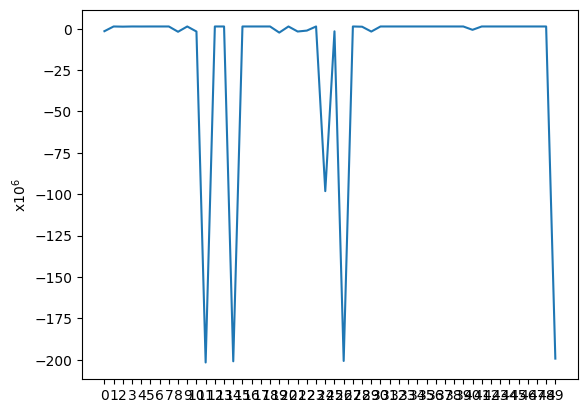

CPU times: user 1d 13h 42min 11s, sys: 7min 56s, total: 1d 13h 50min 8s
Wall time: 1d 19h 38min 58s


[np.float64(-150405.609887),
 np.float64(133580.0),
 np.float64(123510.0),
 np.float64(133540.0),
 np.float64(131930.0),
 np.float64(133420.0),
 np.float64(133480.0),
 np.float64(133600.0),
 np.float64(-185439.215045),
 np.float64(133620.0),
 np.float64(-170511.560489),
 np.float64(-20159369.329434),
 np.float64(133600.0),
 np.float64(133580.0),
 np.float64(-20088875.1282),
 np.float64(133560.0),
 np.float64(133440.0),
 np.float64(133580.0),
 np.float64(133580.0),
 np.float64(-235393.89401600003),
 np.float64(133380.0),
 np.float64(-170626.70009),
 np.float64(-114655.64084600001),
 np.float64(133580.0),
 np.float64(-9811479.604692),
 np.float64(-158544.88287799997),
 np.float64(-20067673.731922995),
 np.float64(133620.0),
 np.float64(119710.0),
 np.float64(-172850.542983),
 np.float64(133600.0),
 np.float64(133540.0),
 np.float64(133560.0),
 np.float64(133580.0),
 np.float64(133620.0),
 np.float64(133580.0),
 np.float64(133600.0),
 np.float64(133580.0),
 np.float64(133410.0),
 np.float

In [6]:
%%time
from sb3_contrib import CrossQ

# Create the environment
vec_env = make_vec_env('MultiRobotEnv-v0', env_kwargs={'field_info':json_dict[f"set1"], 'render_mode': None, 'num_robots':num_robots}, n_envs = 4) # Make vector environment
eval_env = make_vec_env('MultiRobotEnv-v0', env_kwargs={'field_info':json_dict[f"set1"], 'render_mode': None, 'num_robots':num_robots}, n_envs = 4) # Make vector environment
eval_callback = EvalCallback(eval_env, eval_freq=50000, callback_after_eval=stop_train_callback, verbose=1)

mean_rewards = []
best_reward = -1e10

# Objective function for optimization
def objective(trial):
    global best_reward
    # Suggest hyperparameters
    # n_steps = trial.suggest_categorical("n_steps", [5, 10, 20])
    gamma = trial.suggest_float("gamma", 0.90, 0.99)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    # ent_coef = trial.suggest_float("ent_coef", 0.0, 0.05)
    # vf_coef = trial.suggest_float("vf_coef", 0.2, 0.7)
    # gae_lambda = trial.suggest_float("gae_lambda", 0.9, 1.0)
    # max_grad_norm = trial.suggest_float("max_grad_norm", 0.3, 0.99)
    buffer_size = trial.suggest_int('buffer_size', 1000, 100000, step=1000)

    # Train the CrossQ model with sampled hyperparameters
    model = CrossQ("MlpPolicy",
                vec_env,
                gamma=gamma,
                learning_rate=learning_rate,
                buffer_size = buffer_size,
                verbose=0,
                tensorboard_log=log_path+"_CrossQ_optuna")

    # model.learn(total_timesteps=time_steps,  callback=[eval_callback, logger])
    try:
        model.learn(total_timesteps=time_steps,  callback=[eval_callback, logger])
    except Exception as e:
        print("Training failed with error:")
        traceback.print_exc()  # Optional: prints the full stack trace
        print("*"*50)
    vec_env.reset()
    eval_env.reset()

    # Evaluate model performance
    mean_reward, _ = evaluate_policy(model, vec_env, n_eval_episodes=10, deterministic=True)
    mean_rewards.append(mean_reward)

    if best_reward < mean_reward:
        best_reward = mean_reward
        # model.save(weights_path)
    return mean_reward

# Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=n_trials)

# Best hyperparameters
print("Best hyperparameters:", study.best_params)
print("Best mean reward:", best_reward)

scaled_rewards = [x/100000 for x in mean_rewards]
x_vals = list(range(len(mean_rewards)))
plt.figure()
plt.xticks(x_vals)
plt.plot(scaled_rewards)
plt.ylabel("x$10^6$")
plt.show()
mean_rewards

/home/c/choton/miniconda3/envs/rl4pag/lib/python3.11/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/c/choton/miniconda3/envs/rl4pag/lib/python3.11/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
[I 2026-01-21 10:16:34,855] A new study created in memory with name: no-name-445b13ad-e009-41e1-aff7-094cfba45745


/home/c/choton/miniconda3/envs/rl4pag/lib/python3.11/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Eval num_timesteps=200000, episode_reward=-101329.94 +/- 0.00
Episode length: 37.00 +/- 0.00
New best mean reward!
Eval num_timesteps=400000, episode_reward=-9386607.64 +/- 0.00
Episode length: 1000.00 +/- 0.00


[I 2026-01-21 10:32:05,045] Trial 0 finished with value: -9515129.201617 and parameters: {'n_steps': 1024, 'gamma': 0.9515285816698782, 'learning_rate': 0.00023732999911859246, 'ent_coef': 0.0021181938583484327, 'vf_coef': 0.24000816107163492, 'gae_lambda': 0.9323962167988405, 'max_grad_norm': 0.8964921852345316}. Best is trial 0 with value: -9515129.201617.


Eval num_timesteps=96192, episode_reward=-101637.08 +/- 0.00
Episode length: 43.00 +/- 0.00
Eval num_timesteps=296192, episode_reward=-85375.71 +/- 0.00
Episode length: 46.00 +/- 0.00
New best mean reward!
Eval num_timesteps=496192, episode_reward=-9943239.20 +/- 0.00
Episode length: 1000.00 +/- 0.00


...

Eval num_timesteps=188288, episode_reward=-115134.23 +/- 0.00
Episode length: 72.00 +/- 0.00
Eval num_timesteps=388288, episode_reward=-107413.74 +/- 0.00
Episode length: 52.00 +/- 0.00


[I 2026-01-21 22:59:43,777] Trial 48 finished with value: -98805.219992 and parameters: {'n_steps': 1024, 'gamma': 0.9636187357908128, 'learning_rate': 0.00013727779812019777, 'ent_coef': 0.04339065592832554, 'vf_coef': 0.201609166277212, 'gae_lambda': 0.9674672138531685, 'max_grad_norm': 0.3733345208924299}. Best is trial 11 with value: -83350.44220199999.


Eval num_timesteps=84480, episode_reward=-19973814.68 +/- 0.00
Episode length: 1000.00 +/- 0.00
Eval num_timesteps=284480, episode_reward=-19962924.96 +/- 0.00
Episode length: 1000.00 +/- 0.00
Eval num_timesteps=484480, episode_reward=-19932397.22 +/- 0.00
Episode length: 1000.00 +/- 0.00


[I 2026-01-21 23:11:51,343] Trial 49 finished with value: -19912186.970885 and parameters: {'n_steps': 1024, 'gamma': 0.9714429318672776, 'learning_rate': 0.03675933039427739, 'ent_coef': 0.011624577546718754, 'vf_coef': 0.6983842720972439, 'gae_lambda': 0.981182825513506, 'max_grad_norm': 0.4726773782863024}. Best is trial 11 with value: -83350.44220199999.


Best hyperparameters: {'n_steps': 1024, 'gamma': 0.9359958820301953, 'learning_rate': 0.0007922596053353523, 'ent_coef': 0.01808082354940291, 'vf_coef': 0.494005221251412, 'gae_lambda': 0.9635085883831745, 'max_grad_norm': 0.31116388386964106}
Best mean reward: -83350.44220199999


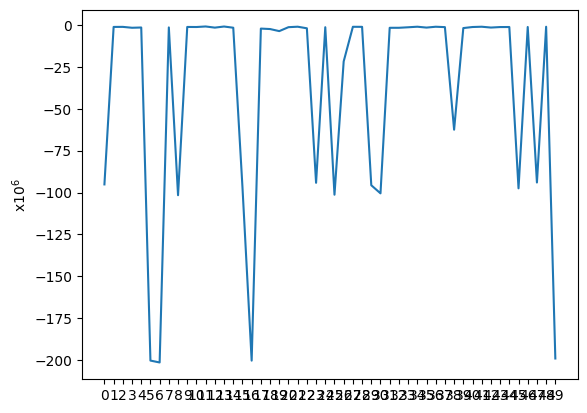

CPU times: user 9h 56min 4s, sys: 1min 30s, total: 9h 57min 34s
Wall time: 12h 55min 16s


[np.float64(-9515129.201617),
 np.float64(-110264.253328),
 np.float64(-106846.080758),
 np.float64(-160160.13424800002),
 np.float64(-144550.954414),
 np.float64(-20035658.718362),
 np.float64(-20149279.329434),
 np.float64(-139701.08003100002),
 np.float64(-10160260.0),
 np.float64(-111653.81776600001),
 np.float64(-115370.0),
 np.float64(-83350.44220199999),
 np.float64(-151622.088862),
 np.float64(-86204.96552900001),
 np.float64(-157130.0),
 np.float64(-9673153.096662),
 np.float64(-20038289.329434),
 np.float64(-209230.0),
 np.float64(-236480.415166),
 np.float64(-360330.0),
 np.float64(-125280.0),
 np.float64(-97105.47933999999),
 np.float64(-191482.14195999998),
 np.float64(-9419422.630153),
 np.float64(-127772.935809),
 np.float64(-10130260.0),
 np.float64(-2170602.0678059994),
 np.float64(-102223.87578799999),
 np.float64(-105067.84380900001),
 np.float64(-9565524.919691),
 np.float64(-10049038.110194),
 np.float64(-162200.001626),
 np.float64(-161486.76596),
 np.float64(-131

In [7]:
%%time
from stable_baselines3 import PPO

# Create the environment
vec_env = make_vec_env('MultiRobotEnv-v0', env_kwargs={'field_info':json_dict[f"set1"], 'render_mode': None, 'num_robots':num_robots}, n_envs = 4) # Make vector environment
eval_env = make_vec_env('MultiRobotEnv-v0', env_kwargs={'field_info':json_dict[f"set1"], 'render_mode': None, 'num_robots':num_robots}, n_envs = 4) # Make vector environment
eval_callback = EvalCallback(eval_env, eval_freq=50000, callback_after_eval=stop_train_callback, verbose=1)

mean_rewards = []
best_reward = -1e10

# Objective function for optimization
def objective(trial):
    global best_reward
    # Suggest hyperparameters
    n_steps = trial.suggest_categorical("n_steps", [1024, 2048, 4096])
    gamma = trial.suggest_float("gamma", 0.90, 0.99)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 5e-2, log=True)
    ent_coef = trial.suggest_float("ent_coef", 0.0, 0.05)
    vf_coef = trial.suggest_float("vf_coef", 0.2, 0.7)
    gae_lambda = trial.suggest_float("gae_lambda", 0.9, 1.0)
    max_grad_norm = trial.suggest_float("max_grad_norm", 0.3, 0.99)

    # Train the PPO model with sampled hyperparameters
    model = PPO("MlpPolicy",
                vec_env,
                n_steps=n_steps,
                gamma=gamma,
                learning_rate=learning_rate,
                gae_lambda=gae_lambda,
                ent_coef=ent_coef,
                vf_coef=vf_coef,
                max_grad_norm = max_grad_norm,
                verbose=0,
                tensorboard_log=log_path+"_PPO_optuna")

    # model.learn(total_timesteps=time_steps, callback=[eval_callback, logger])
    try:
        model.learn(total_timesteps=time_steps,  callback=[eval_callback, logger])
    except Exception as e:
        print("Training failed with error:")
        traceback.print_exc()  # Optional: prints the full stack trace
        print("*"*50)
    vec_env.reset()
    eval_env.reset()

    # Evaluate model performance
    mean_reward, _ = evaluate_policy(model, vec_env, n_eval_episodes=10, deterministic=True)
    mean_rewards.append(mean_reward)

    if best_reward < mean_reward:
        best_reward = mean_reward
        # model.save(weights_path)
    return mean_reward

# Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=n_trials)

# Best hyperparameters
print("Best hyperparameters:", study.best_params)
print("Best mean reward:", best_reward)

scaled_rewards = [x/100000 for x in mean_rewards]
x_vals = list(range(len(mean_rewards)))
plt.figure()
plt.xticks(x_vals)
plt.plot(scaled_rewards)
plt.ylabel("x$10^6$")
plt.show()
mean_rewards

In [8]:
%%time
from sb3_contrib import TQC

# Create the environment
vec_env = make_vec_env('MultiRobotEnv-v0', env_kwargs={'field_info':json_dict[f"set1"], 'render_mode': None, 'num_robots':num_robots}, n_envs = 4) # Make vector environment
eval_env = make_vec_env('MultiRobotEnv-v0', env_kwargs={'field_info':json_dict[f"set1"], 'render_mode': None, 'num_robots':num_robots}, n_envs = 4) # Make vector environment
eval_callback = EvalCallback(eval_env, eval_freq=50000, callback_after_eval=stop_train_callback, verbose=1)

mean_rewards = []
best_reward = -1e10

# Objective function for optimization
def objective(trial):
    global best_reward
    # Suggest hyperparameters
    # n_steps = trial.suggest_categorical("n_steps", [5, 10, 20])
    gamma = trial.suggest_float("gamma", 0.90, 0.99)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 5e-2, log=True)
    # ent_coef = trial.suggest_float("ent_coef", 0.0, 0.05)
    # vf_coef = trial.suggest_float("vf_coef", 0.2, 0.7)
    # gae_lambda = trial.suggest_float("gae_lambda", 0.9, 1.0)
    # max_grad_norm = trial.suggest_float("max_grad_norm", 0.3, 0.99)
    buffer_size = trial.suggest_int('buffer_size', 1000, 100000, step=1000)

    # Train the TQC model with sampled hyperparameters
    model = TQC("MlpPolicy",
                vec_env,
                gamma=gamma,
                learning_rate=learning_rate,
                buffer_size = buffer_size,
                verbose=0,
                tensorboard_log=log_path+"_TQC_optuna")

    # model.learn(total_timesteps=time_steps,  callback=[eval_callback, logger])
    try:
        model.learn(total_timesteps=time_steps,  callback=[eval_callback, logger])
    except Exception as e:
        print("Training failed with error:")
        traceback.print_exc()  # Optional: prints the full stack trace
        print("*"*50)
    vec_env.reset()
    eval_env.reset()

    # Evaluate model performance
    mean_reward, _ = evaluate_policy(model, vec_env, n_eval_episodes=10, deterministic=True)
    mean_rewards.append(mean_reward)

    if best_reward < mean_reward:
        best_reward = mean_reward
        # model.save(weights_path)
    return mean_reward

# Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=n_trials)

# Best hyperparameters
print("Best hyperparameters:", study.best_params)
print("Best mean reward:", best_reward)

scaled_rewards = [x/100000 for x in mean_rewards]
x_vals = list(range(len(mean_rewards)))
plt.figure()
plt.xticks(x_vals)
plt.plot(scaled_rewards)
plt.ylabel("x$10^6$")
plt.show()
mean_rewards

[I 2026-01-21 23:11:51,669] A new study created in memory with name: no-name-14500cd7-55fa-4cc3-9232-250ea4fd0d62


Eval num_timesteps=200000, episode_reward=-138443.90 +/- 0.00
Episode length: 1000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=400000, episode_reward=-109215.31 +/- 0.00
Episode length: 1000.00 +/- 0.00
New best mean reward!


[I 2026-01-21 23:44:17,855] Trial 0 finished with value: -102063.974433 and parameters: {'gamma': 0.9795751231631046, 'learning_rate': 0.0012102772722251257, 'buffer_size': 93000}. Best is trial 0 with value: -102063.974433.


Eval num_timesteps=100000, episode_reward=-19927198.47 +/- 0.00
Episode length: 1000.00 +/- 0.00
Eval num_timesteps=300000, episode_reward=-172945.45 +/- 0.00
Episode length: 1000.00 +/- 0.00
Eval num_timesteps=500000, episode_reward=-164647.91 +/- 0.00
Episode length: 1000.00 +/- 0.00


[I 2026-01-22 00:27:49,041] Trial 1 finished with value: -164288.48112199997 and parameters: {'gamma': 0.9678885943468571, 'learning_rate': 0.0003827444751880179, 'buffer_size': 18000}. Best is trial 0 with value: -102063.974433.


...

[I 2026-01-22 01:00:47,902] Trial 2 finished with value: -197670.398584 and parameters: {'gamma': 0.9693352340871583, 'learning_rate': 0.00015257566122565952, 'buffer_size': 40000}. Best is trial 0 with value: -102063.974433.


Training failed with error:


Traceback (most recent call last):
  File "<timed exec>", line 35, in objective
  File "/home/c/choton/miniconda3/envs/rl4pag/lib/python3.11/site-packages/sb3_contrib/tqc/tqc.py", line 302, in learn
    return super().learn(
           ^^^^^^^^^^^^^^
  File "/home/c/choton/miniconda3/envs/rl4pag/lib/python3.11/site-packages/stable_baselines3/common/off_policy_algorithm.py", line 328, in learn
    rollout = self.collect_rollouts(
              ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/c/choton/miniconda3/envs/rl4pag/lib/python3.11/site-packages/stable_baselines3/common/off_policy_algorithm.py", line 557, in collect_rollouts
    actions, buffer_actions = self._sample_action(learning_starts, action_noise, env.num_envs)
                              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/c/choton/miniconda3/envs/rl4pag/lib/python3.11/site-packages/stable_baselines3/common/off_policy_algorithm.py", line 390, in _sample_action
    unscaled_action, _ = self.

**************************************************


ValueError: Expected parameter loc (Tensor of shape (4, 6)) of distribution Normal(loc: torch.Size([4, 6]), scale: torch.Size([4, 6])) to satisfy the constraint Real(), but found invalid values:
tensor([[nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan]], device='cuda:0')

[I 2026-01-22 01:01:23,810] A new study created in memory with name: no-name-61a655a5-7901-47ae-8afc-6f1cd5ccc75b


/home/c/choton/miniconda3/envs/rl4pag/lib/python3.11/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run TRPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Eval num_timesteps=200000, episode_reward=-172262.42 +/- 0.00
Episode length: 1000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=400000, episode_reward=-161009.15 +/- 0.00
Episode length: 1000.00 +/- 0.00
New best mean reward!


[I 2026-01-22 01:06:56,195] Trial 0 finished with value: -155267.069078 and parameters: {'n_steps': 4096, 'gamma': 0.9055083335218523, 'learning_rate': 0.0021809475408753705, 'gae_lambda': 0.9044750901717957}. Best is trial 0 with value: -155267.069078.


Eval num_timesteps=92096, episode_reward=-127843.43 +/- 0.00
Episode length: 1000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=292096, episode_reward=-157850.00 +/- 0.00
Episode length: 1000.00 +/- 0.00
Eval num_timesteps=492096, episode_reward=-163368.41 +/- 0.00
Episode length: 1000.00 +/- 0.00


...

Eval num_timesteps=200000, episode_reward=128300.00 +/- 0.00
Episode length: 204.00 +/- 0.00
Stopping training because there was no new best model in the last 106 evaluations


[I 2026-01-22 05:03:57,110] Trial 48 finished with value: 128300.0 and parameters: {'n_steps': 1024, 'gamma': 0.9466057097604778, 'learning_rate': 0.002351747109552231, 'gae_lambda': 0.9296565684693353}. Best is trial 6 with value: 133540.0.


Eval num_timesteps=200000, episode_reward=-156822.44 +/- 0.00
Episode length: 1000.00 +/- 0.00
Stopping training because there was no new best model in the last 107 evaluations


[I 2026-01-22 05:06:10,247] Trial 49 finished with value: -156822.442479 and parameters: {'n_steps': 1024, 'gamma': 0.9299181993969421, 'learning_rate': 0.00017464323486690778, 'gae_lambda': 0.9354389555680735}. Best is trial 6 with value: 133540.0.


Best hyperparameters: {'n_steps': 1024, 'gamma': 0.9368724492568504, 'learning_rate': 0.00011448559812373766, 'gae_lambda': 0.942831749331419}
Best mean reward: 133540.0


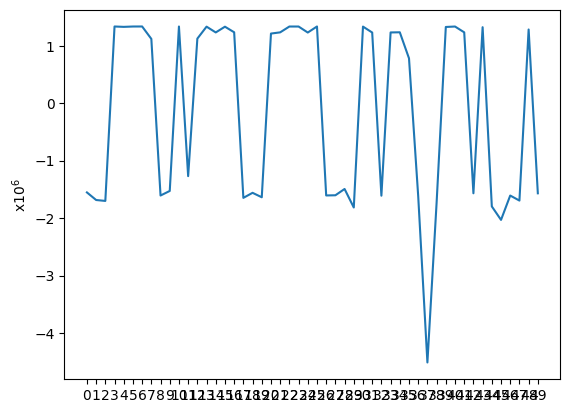

CPU times: user 3h 40min 55s, sys: 33 s, total: 3h 41min 28s
Wall time: 4h 4min 46s


[np.float64(-155267.069078),
 np.float64(-168475.345705),
 np.float64(-170087.126889),
 np.float64(133520.0),
 np.float64(132870.0),
 np.float64(133469.87620900004),
 np.float64(133540.0),
 np.float64(111920.0),
 np.float64(-160662.304889),
 np.float64(-152720.0),
 np.float64(133500.0),
 np.float64(-126926.90644899997),
 np.float64(112380.0),
 np.float64(133240.0),
 np.float64(123170.0),
 np.float64(133160.0),
 np.float64(123430.0),
 np.float64(-164739.20051599998),
 np.float64(-155967.63266099998),
 np.float64(-163710.0),
 np.float64(121191.65739700003),
 np.float64(123310.0),
 np.float64(133460.0),
 np.float64(133460.87738),
 np.float64(122990.0),
 np.float64(133520.0),
 np.float64(-160552.44880299998),
 np.float64(-160245.565164),
 np.float64(-149290.0),
 np.float64(-181520.0),
 np.float64(133340.0),
 np.float64(123010.0),
 np.float64(-160967.20974500003),
 np.float64(123150.0),
 np.float64(123430.0),
 np.float64(78110.0),
 np.float64(-161779.91617099996),
 np.float64(-451251.725822

In [9]:
%%time
from sb3_contrib import TRPO

# Create the environment
vec_env = make_vec_env('MultiRobotEnv-v0', env_kwargs={'field_info':json_dict[f"set1"], 'render_mode': None, 'num_robots':num_robots}, n_envs = 4) # Make vector environment
eval_env = make_vec_env('MultiRobotEnv-v0', env_kwargs={'field_info':json_dict[f"set1"], 'render_mode': None, 'num_robots':num_robots}, n_envs = 4) # Make vector environment
eval_callback = EvalCallback(eval_env, eval_freq=50000, callback_after_eval=stop_train_callback, verbose=1)

mean_rewards = []
best_reward = -1e10

# Objective function for optimization
def objective(trial):
    global best_reward
    # Suggest hyperparameters
    n_steps = trial.suggest_categorical("n_steps", [1024, 2048, 4096])
    gamma = trial.suggest_float("gamma", 0.90, 0.99)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 5e-2, log=True)
    gae_lambda = trial.suggest_float("gae_lambda", 0.9, 1.0)

    # Train the TRPO model with sampled hyperparameters
    model = TRPO("MlpPolicy",
                vec_env,
                n_steps=n_steps,
                gamma=gamma,
                learning_rate=learning_rate,
                gae_lambda=gae_lambda,
                verbose=0,
                tensorboard_log=log_path+"_TRPO_optuna")

    try:
        model.learn(total_timesteps=time_steps,  callback=[eval_callback, logger])
        vec_env.reset()
        eval_env.reset()
        # Evaluate model performance
        mean_reward, _ = evaluate_policy(model, vec_env, n_eval_episodes=10, deterministic=True)
        mean_rewards.append(mean_reward)
    except Exception as e:
        print("Training failed with error:")
        traceback.print_exc()  # Optional: prints the full stack trace
        print("*"*50)
        vec_env.reset()
        eval_env.reset()
        mean_reward = -1e5
        mean_rewards.append(mean_reward)
    if best_reward < mean_reward:
        best_reward = mean_reward
        # model.save(weights_path)
    return mean_reward

# Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=n_trials)

# Best hyperparameters
print("Best hyperparameters:", study.best_params)
print("Best mean reward:", best_reward)

scaled_rewards = [x/100000 for x in mean_rewards]
x_vals = list(range(len(mean_rewards)))
plt.figure()
plt.xticks(x_vals)
plt.plot(scaled_rewards)
plt.ylabel("x$10^6$")
plt.show()
mean_rewards